In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

prototype_NRB = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/26-01-2026.csv")
prototype_NRB

,range_m,00.05,00.35,01.05,01.35,02.05,02.35,03.05,03.35,04.05,...,19.05,19.35,20.05,20.35,21.05,21.35,22.05,22.35,23.05,23.35
0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,3.75,0.000050,0.000071,0.000047,0.000054,0.000043,0.000051,0.000044,0.000146,0.000112,...,0.000141,0.000127,0.000119,0.000048,0.000042,0.000142,0.000039,0.000144,0.000074,0.000113
2,7.50,0.000312,0.000553,0.000281,0.000340,0.000241,0.000309,0.000253,0.001596,0.001066,...,0.001823,0.001493,0.001301,0.000287,0.000247,0.001711,0.000219,0.001714,0.000576,0.001180
3,11.25,0.000968,0.001848,0.000840,0.001070,0.000679,0.000933,0.000712,0.004862,0.003307,...,0.006501,0.005209,0.004489,0.000887,0.000732,0.005838,0.000625,0.005815,0.001896,0.003833
4,15.00,0.001721,0.003286,0.001494,0.001903,0.001207,0.001658,0.001265,0.008631,0.005869,...,0.011549,0.009253,0.007974,0.001577,0.001302,0.010368,0.001111,0.010327,0.003369,0.006807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,14981.25,-1.083239,-0.883833,-1.054446,-1.150221,-1.362754,-1.019934,-1.296968,-0.761901,-0.926122,...,-0.844521,-1.002768,-1.054841,-1.277765,-1.123081,-1.236424,-1.236499,-1.028746,-1.033038,-0.945965
3996,14985.00,-0.958644,-0.884276,-0.994148,-1.150797,-1.250649,-1.020445,-1.297617,-1.287270,-1.202316,...,-1.131133,-1.299428,-1.250087,-1.278405,-1.233627,-1.237043,-1.287770,-1.029261,-1.115139,-1.043481
3997,14988.75,-1.021724,-0.884718,-0.994646,-1.085044,-1.420540,-1.084408,-1.412537,-0.972764,-1.202918,...,-0.940811,-1.102541,-1.153305,-1.401534,-0.904128,-1.131659,-1.339091,-1.244665,-1.197322,-1.141095
3998,14992.50,-1.210129,-1.039026,-1.116917,-1.151949,-1.251901,-1.021467,-1.184590,-1.183456,-1.019516,...,-0.750297,-1.004275,-1.348795,-1.157135,-1.179815,-0.920113,-1.136953,-1.137790,-1.197921,-1.044526


In [2]:
df = prototype_NRB.copy()

r = df["range_m"].to_numpy(float)

# all time columns (everything except range_m)
time_cols = [c for c in df.columns if c != "range_m"]

# NRB as 2D matrix: shape (n_range, n_time)
NRB = df[time_cols].apply(pd.to_numeric, errors="coerce").to_numpy(float)

print("r:", r.shape, "NRB:", NRB.shape)  # (n_range,) (n_range, n_time)

r: (4000,) NRB: (4000, 48)


In [3]:
def time_str_to_minutes(t: str) -> int:
    hh, mm = t.split(".")
    return int(hh) * 60 + int(mm)

t_min = np.array([time_str_to_minutes(c) for c in time_cols], dtype=int)

In [18]:
import numpy as np

def haar_wct(nrb, m):
    """
    Haar Wavelet Covariance Transform (discrete)
    W[i] = mean(right) - mean(left)

    For a sharp DROP in signal:
      left mean (below)  = higher
      right mean (above) = lower
    => W becomes strongly NEGATIVE (a trough)
    """
    y = np.asarray(nrb, float)
    W = np.full_like(y, np.nan, dtype=float)

    for i in range(m, len(y) - m):
        W[i] = np.nanmean(y[i:i+m]) - np.nanmean(y[i-m:i])

    return W


def pick_pbl_from_profile_haar(r, nrb, rmin=1500, rmax=2500, a_m=200):
    """
    PBL detection using Haar-WCT (PDF-faithful logic)
    Choose the strongest DROP => most negative W within [rmin, rmax]

    a_m : Haar dilation in meters (paper's 'a')
    """
    r = np.asarray(r, float)
    y = np.asarray(nrb, float)

    mask = np.isfinite(r) & np.isfinite(y)
    r = r[mask]
    y = y[mask]

    if len(r) < 10:
        return np.nan

    # range resolution
    dr = float(np.nanmedian(np.diff(r)))

    # half-window in bins (m = a / Δr)
    m = max(1, int(round(a_m / dr)))

    # Haar WCT
    W = haar_wct(y, m)

    # search window + valid W
    win = (r >= rmin) & (r <= rmax) & np.isfinite(W)
    if not np.any(win):
        return np.nan

    # ✅ strongest drop = most negative W
    idx = np.nanargmin(W[win])
    return float(r[win][idx])


In [24]:
pbl = {
    c: pick_pbl_from_profile_haar(
        r,
        df[c].to_numpy(float),
        rmin=1500,
        rmax=2500,
        a_m=200   # <-- physical Haar scale (meters)
    )
    for c in time_cols
}

pbl_df = pd.DataFrame({
    "time_str": list(pbl.keys()),
    "pbl_m": list(pbl.values())
})

pbl_df


,time_str,pbl_m
0,00.05,2092.50
1,00.35,2092.50
2,01.05,2073.75
3,01.35,2051.25
4,02.05,2081.25
5,02.35,2070.00
6,03.05,2115.00
7,03.35,2085.00
8,04.05,2043.75
9,04.35,2002.50


In [7]:
import numpy as np
import matplotlib.pyplot as plt
def haar_wct(y, m):
    y = np.asarray(y, float)
    W = np.full_like(y, np.nan, dtype=float)
    for i in range(m, len(y) - m):
        W[i] = np.nanmean(y[i:i+m]) - np.nanmean(y[i-m:i])
    return W

def pick_pbl_from_profile_haar(r, nrb, rmin=300, rmax=2500, a_m=200):
    r = np.asarray(r, float)
    y = np.asarray(nrb, float)

    mask = np.isfinite(r) & np.isfinite(y)
    r = r[mask]; y = y[mask]
    if len(r) < 10:
        return np.nan

    dr = float(np.nanmedian(np.diff(r)))
    m = max(1, int(round(a_m / dr)))

    W = haar_wct(y, m)

    win = (r >= rmin) & (r <= rmax) & np.isfinite(W)
    if not np.any(win):
        return np.nan

    # ✅ drop = most negative W
    idx = np.nanargmin(W[win])
    return float(r[win][idx])


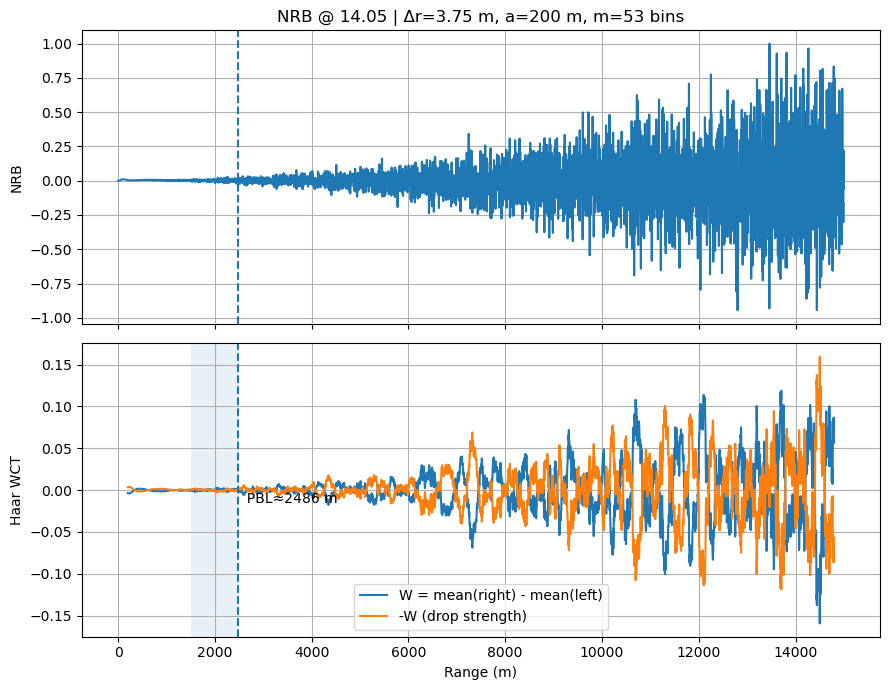

In [48]:
import matplotlib.pyplot as plt

def plot_profile_and_haar(df, time_col, a_m=200, rmin=2000, rmax=2200):
    r = df["range_m"].to_numpy(float)
    y = df[time_col].to_numpy(float)

    mask = np.isfinite(r) & np.isfinite(y)
    r = r[mask]; y = y[mask]

    dr = float(np.nanmedian(np.diff(r)))
    m = max(1, int(round(a_m / dr)))
    W = haar_wct(y, m)

    win = (r >= rmin) & (r <= rmax) & np.isfinite(W)
    pbl = np.nan
    if np.any(win):
        pbl = float(r[win][np.nanargmin(W[win])])  # drop = min

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    ax1.plot(r, y)
    if np.isfinite(pbl):
        ax1.axvline(pbl, linestyle="--")
    ax1.set_ylabel("NRB")
    ax1.set_title(f"NRB @ {time_col} | Δr={dr:.2f} m, a={a_m} m, m={m} bins")
    ax1.grid(True)

    ax2.plot(r, W, label="W = mean(right) - mean(left)")
    ax2.plot(r, -W, label="-W (drop strength)")
    ax2.axvspan(rmin, rmax, alpha=0.1)
    if np.isfinite(pbl):
        ax2.axvline(pbl, linestyle="--")
        ax2.text(pbl, np.nanmin(W[win]), f"  PBL≈{pbl:.0f} m", va="top")
    ax2.set_xlabel("Range (m)")
    ax2.set_ylabel("Haar WCT")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()
plot_profile_and_haar(df, "14.05", a_m=200, rmin=1500, rmax=2500)


In [30]:
MiniMPL_NRB = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/pbls_26-01-2026_0005_0035_to_2335.csv")
MiniMPL_NRB

,day,timestamp,pbls_km,pbls_m,min_pbls_m,max_pbls_m
0,26-01-2026,2026-01-26 00:05:00,2.098547,2098.5472,1798.5472,2398.5472
1,26-01-2026,2026-01-26 00:35:00,2.128526,2128.5264,1828.5264,2428.5264
2,26-01-2026,2026-01-26 01:05:00,2.098547,2098.5472,1798.5472,2398.5472
3,26-01-2026,2026-01-26 01:35:00,2.038589,2038.5888,1738.5888,2338.5888
4,26-01-2026,2026-01-26 02:05:00,2.098547,2098.5472,1798.5472,2398.5472
5,26-01-2026,2026-01-26 02:35:00,2.098547,2098.5472,1798.5472,2398.5472
6,26-01-2026,2026-01-26 03:05:00,2.128526,2128.5264,1828.5264,2428.5264
7,26-01-2026,2026-01-26 03:35:00,2.128526,2128.5264,1828.5264,2428.5264
8,26-01-2026,2026-01-26 04:05:00,2.068568,2068.5680,1768.5680,2368.5680
9,26-01-2026,2026-01-26 04:35:00,2.038589,2038.5888,1738.5888,2338.5888


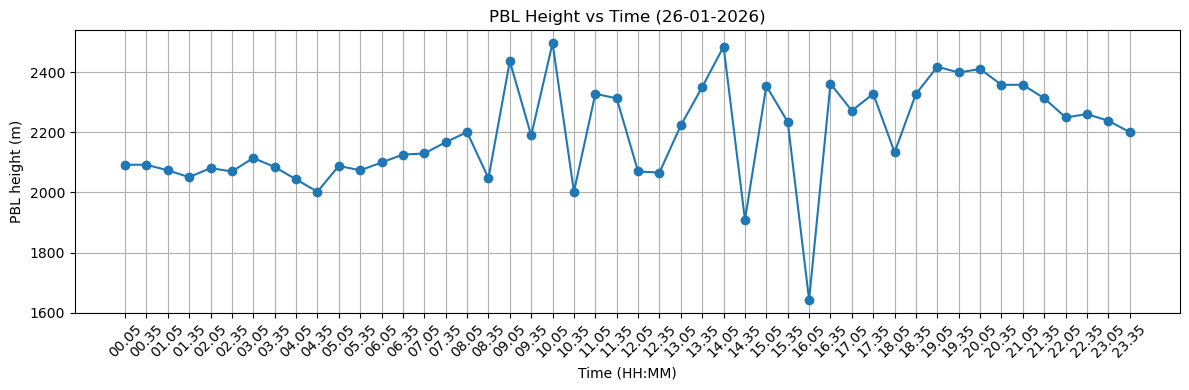

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(pbl_df["time_str"], pbl_df["pbl_m"], marker="o")
plt.xlabel("Time (HH:MM)")
plt.ylabel("PBL height (m)")
plt.title("PBL Height vs Time (26-01-2026)")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


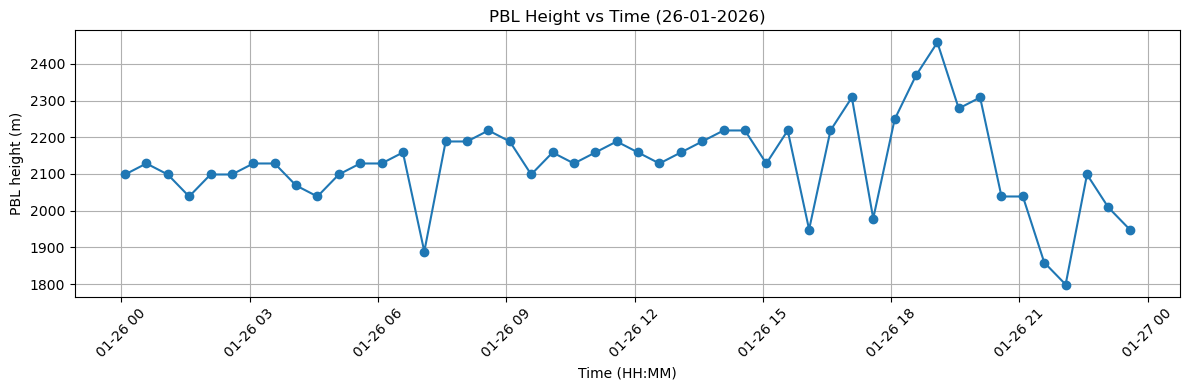

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# plt.plot(pbl_df["time_str"], pbl_df["pbl_m"], marker="o")
plt.plot(MiniMPL_NRB["timestamp"], MiniMPL_NRB["pbls_m"], marker="o")
plt.xlabel("Time (HH:MM)")
plt.ylabel("PBL height (m)")
plt.title("PBL Height vs Time (26-01-2026)")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
